<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/03_language_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 3 · Language models · taste project*

# How does a model predict the next word?

> **In short**
>
> **How does a model predict the next word?**
>
> It learns, from a lot of text, how likely each possible next piece of text is, given what came before. Writing is repeating that: pick a likely next piece, add it, predict again.

## Where you'll end up

By the end you will have built:

1. **A letter-pair counter** (a bigram model) that writes word-like gibberish.
2. **A tiny transformer**, the same design as large language models, trained on a public-domain book. It writes new text in the book's style.
3. **Pictures of attention**: which earlier characters the model looks at when it predicts the next one.
4. **A byte-pair encoder**, the method that splits text into the tokens real models use.

Running every cell takes about 5 minutes on a CPU.

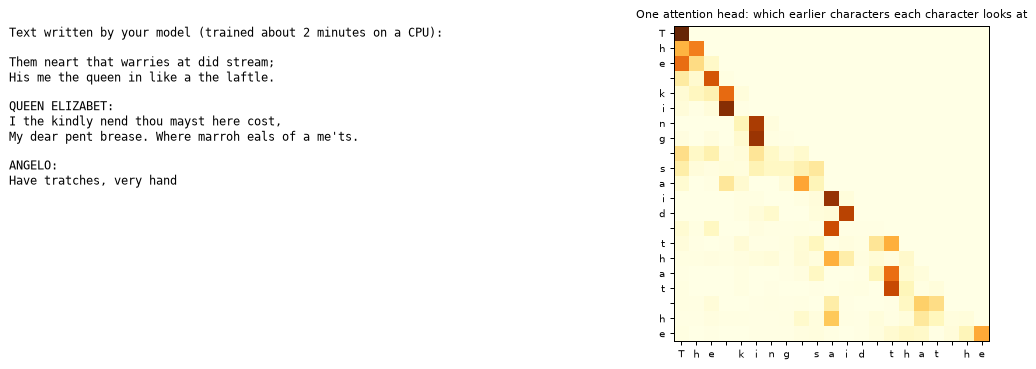

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up.
- Exercise solutions are in collapsed cells. In Colab, double-click a solution's title to open it.
- A GPU is not needed. (Runtime → Change runtime type → GPU would make training faster, but the code runs on CPU as written.)

## 1. The problem: what comes next?

Type "th" on a phone and it suggests "the". **How can a program do that without understanding English?**

It can learn from examples. Feed it a book. For every position, the next character is a free example of "what comes next".
A 700,000-character book gives 700,000 examples.

In [1]:
import urllib.request

SOURCES = [
    ("Pride and Prejudice, Jane Austen (Project Gutenberg)", "https://www.gutenberg.org/cache/epub/1342/pg1342.txt"),
    ("Tiny Shakespeare (Shakespeare's plays)", "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"),
]
text, source = None, None
for name, url in SOURCES:
    try:
        with urllib.request.urlopen(url, timeout=20) as r:
            text = r.read().decode("utf-8", errors="ignore")
        source = name
        break
    except Exception as e:
        print(f"could not download {name}: {e}")
if text is None:
    # last resort: a short public-domain passage, so the notebook still runs offline
    source = "a short built-in passage (offline fallback)"
    text = ("It is a truth universally acknowledged, that a single man in possession of a good fortune, "
            "must be in want of a wife. ") * 400

if "gutenberg" in source.lower():
    start = text.find("Chapter 1")                       # skip the licence header and footer
    end = text.find("*** END OF THE PROJECT GUTENBERG")
    text = text[start if start > 0 else 0: end if end > 0 else None]
text = text[:1_000_000]
print("text:", source, "-", f"{len(text):,}", "characters")

print(text[:400])

could not download Pride and Prejudice, Jane Austen (Project Gutenberg): <urlopen error Tunnel connection failed: 403 Forbidden>


text: Tiny Shakespeare (Shakespeare's plays) - 1,000,000 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 


🐍 **Python notes**
- `for name, url in SOURCES:` unpacks each pair. `try:` / `except` tries the next source if a download fails.
- `text[:400]` is the first 400 characters (**slicing** works on strings and lists).
- `f"{len(text):,}"` prints a number with thousands separators.

## 2. Text as numbers

A model works on numbers. So give every different character a number.

In [2]:
chars = sorted(set(text))                       # every different character, in order
stoi = {c: i for i, c in enumerate(chars)}      # character -> number
itos = {i: c for c, i in stoi.items()}          # number -> character
print(len(chars), "different characters:", repr("".join(chars)))
print("'hello' ->", [stoi[c] for c in "hello"])

65 different characters: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
'hello' -> [46, 43, 50, 50, 53]


🐍 **Python notes**
- `set(text)` keeps one copy of each character; `sorted` puts them in order.
- `{c: i for i, c in enumerate(chars)}` is a **dict comprehension**: it builds a dict in one line.
- `repr(s)` shows a string with its quotes and escape codes, so you can see `\n` (new line).

**What it's called:** turning text into a list of numbers is **tokenisation**; each unit (here, one character) is a **token**. Section 7 shows the bigger tokens real models use.

## 3. The simplest predictor: count pairs

For every character, count which character comes next. Then the chance of each next character is its count divided by the row total.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

V = len(chars)
counts = np.zeros((V, V))
for a, b in zip(text, text[1:]):
    counts[stoi[a], stoi[b]] += 1

probs = (counts + 1) / (counts + 1).sum(axis=1, keepdims=True)    # +1 so nothing is impossible

def top_next(c, k=5):
    row = probs[stoi[c]]
    best = np.argsort(row)[::-1][:k]
    return [(itos[i], round(float(row[i]), 3)) for i in best]

print("after 't':", top_next("t"))
print("after 'q':", top_next("q"))

after 't': [('h', 0.341), (' ', 0.246), ('o', 0.088), ('e', 0.065), ('i', 0.045)]
after 'q': [('u', 0.898), ('z', 0.002), ('y', 0.002), ('w', 0.002), ('x', 0.002)]


🐍 **Python notes**
- `zip(text, text[1:])` pairs each character with the next one.
- `counts.sum(axis=1, keepdims=True)` adds along each row and keeps the shape, so dividing gives row-by-row probabilities. numpy stretches the column of totals across each row; that stretching is called **broadcasting**.
- `np.argsort(row)[::-1]` lists positions from largest to smallest.

### 🤔 Predict first

This model only looks one character back. **If you let it write, what will come out?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

**Word-like gibberish.** Pairs look right, nothing longer holds together. Run the next cell.

</details>

In [4]:
rng = np.random.default_rng(0)
def bigram_write(start="T", length=250):
    out = start
    for _ in range(length):
        out += itos[rng.choice(V, p=probs[stoi[out[-1]]])]
    return out
print(bigram_write())

Tha ETornetl
V:

Whan ashe:ayarin se!
Wine, ges o tilo g is LI ar?
As,
Nonthelyoounerdent stt two; tle tr, it sh s
Ths t gethalof finor:
Thuliou, w ter h pent t hedve!
Windy busitroue rl!
Whe me y,
Turais nfu mod RTENooust V: oocldeano n'sexayoourit t


**How good is it?** Measure it on text the model didn't count. For each character, take the probability the model gave the character that really came next, and average $-\log$ of it.
Lower is better. Guessing uniformly among all characters would score $\log(V)$.

In [5]:
n = int(0.9 * len(text))
held_out = text[n:n + 50_000]
nll = -np.mean([np.log(probs[stoi[a], stoi[b]]) for a, b in zip(held_out, held_out[1:])])
print(f"bigram loss on unseen text: {nll:.3f}    uniform guessing: {np.log(V):.3f}")

bigram loss on unseen text: 2.481    uniform guessing: 4.174


**What it's called:** this score is the **cross-entropy loss** (average negative log-probability of what really happened).
Counting pairs is a **bigram model**. Predicting what comes next, one token at a time, is **next-token prediction**: the job of every language model.

## 4. Looking further back: attention

To do better, each position needs information from **earlier** positions, and it must choose **which** ones matter.
After "The king said that h", the "h" should look back at "said that" more than at "The".

Here is the mechanism, one step at a time:

1. Every position gets a list of numbers describing it (an **embedding**).
2. From it, each position makes three lists: a **query** ("what am I looking for?"), a **key** ("what do I contain?") and a **value** ("what do I pass on?").
3. Score every earlier position: query · key, a **dot product**. A big score means a good match.
4. Turn the scores into weights that add up to 1 (**softmax**), and take the weighted average of the values.
5. Positions may only look backwards: scores for later positions are set to $-\infty$, so their weight is 0.

In [6]:
import torch
import torch.nn.functional as F
torch.manual_seed(0)

T, D = 5, 4                                   # 5 positions, 4 numbers each
x = torch.randn(T, D)                         # pretend embeddings
Wq, Wk, Wv = torch.randn(D, D), torch.randn(D, D), torch.randn(D, D)
q, k, v = x @ Wq, x @ Wk, x @ Wv

scores = q @ k.T / D ** 0.5                   # every query against every key
mask = torch.tril(torch.ones(T, T))           # 1 on and below the diagonal: "earlier or same"
scores = scores.masked_fill(mask == 0, float("-inf"))
weights = F.softmax(scores, dim=-1)
print("attention weights (row = position looking, column = position looked at):")
print(weights.numpy().round(2))
out = weights @ v

attention weights (row = position looking, column = position looked at):
[[1.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.  ]
 [0.81 0.19 0.   0.   0.  ]
 [0.08 0.34 0.47 0.1  0.  ]
 [0.7  0.3  0.   0.   0.  ]]


🐍 **Python notes**
- `@` is matrix multiplication. `q @ k.T` compares every query with every key in one step: a 5 × 5 grid of dot products.
- `torch.tril` keeps the lower triangle of a matrix ("tri-lower").

**What you see:** each row adds up to 1, and everything above the diagonal is 0: no position looks ahead. Row 0 can only look at itself.

**What it's called:** this is **self-attention**; one set of query/key/value weights is one **attention head**. The formula:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right) V$$

Dividing by $\sqrt{d}$ keeps the scores from growing with the list length, so the softmax doesn't become all-or-nothing.

### Check it against PyTorch's built-in version

In [7]:
lib = F.scaled_dot_product_attention(q[None], k[None], v[None], is_causal=True)[0]
print("largest difference from your version:", float((lib - out).abs().max()))

largest difference from your version: 4.76837158203125e-07


## 5. A tiny transformer

A **transformer** stacks blocks. Each block:

1. lets every position look back with several attention heads at once (**multi-head attention**), then
2. passes each position through a small network on its own (an **MLP**).

Each step *adds* to the position's numbers instead of replacing them (a **residual connection**), and **layer norm** keeps the numbers at a steady size.
The last layer turns each position's numbers into one score per character: the prediction for the next character.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
BLOCK = 64          # how many characters the model can look back over
EMBD = 96           # numbers per character inside the model
HEADS = 4
LAYERS = 3

class Head(nn.Module):
    """One attention head: each position takes a weighted average of earlier positions."""
    def __init__(self, size):
        super().__init__()
        self.query = nn.Linear(EMBD, size, bias=False)
        self.key = nn.Linear(EMBD, size, bias=False)
        self.value = nn.Linear(EMBD, size, bias=False)
        self.register_buffer("mask", torch.tril(torch.ones(BLOCK, BLOCK)))
        self.last_weights = None

    def forward(self, x):
        T = x.shape[1]
        q, k, v = self.query(x), self.key(x), self.value(x)
        scores = q @ k.transpose(-2, -1) / k.shape[-1] ** 0.5       # how well each query matches each key
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float("-inf"))   # no looking ahead
        weights = F.softmax(scores, dim=-1)
        self.last_weights = weights.detach()
        return weights @ v

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.heads = nn.ModuleList([Head(EMBD // HEADS) for _ in range(HEADS)])
        self.proj = nn.Linear(EMBD, EMBD)
        self.mlp = nn.Sequential(nn.Linear(EMBD, 4 * EMBD), nn.GELU(), nn.Linear(4 * EMBD, EMBD))
        self.ln1, self.ln2 = nn.LayerNorm(EMBD), nn.LayerNorm(EMBD)

    def forward(self, x):
        x = x + self.proj(torch.cat([h(self.ln1(x)) for h in self.heads], dim=-1))   # look back
        x = x + self.mlp(self.ln2(x))                                                 # think about it
        return x

class TinyGPT(nn.Module):
    def __init__(self, vocab):
        super().__init__()
        self.tok = nn.Embedding(vocab, EMBD)        # a list of numbers for each character
        self.pos = nn.Embedding(BLOCK, EMBD)        # a list of numbers for each position
        self.blocks = nn.Sequential(*[Block() for _ in range(LAYERS)])
        self.ln = nn.LayerNorm(EMBD)
        self.out = nn.Linear(EMBD, vocab)           # back to one score per character

    def forward(self, idx):
        T = idx.shape[1]
        x = self.tok(idx) + self.pos(torch.arange(T))
        return self.out(self.ln(self.blocks(x)))

def get_batch(data, batch=32):
    ix = torch.randint(len(data) - BLOCK - 1, (batch,))
    x = torch.stack([data[i:i + BLOCK] for i in ix])
    y = torch.stack([data[i + 1:i + BLOCK + 1] for i in ix])
    return x, y

@torch.no_grad()
def write(model, start, length=300, temperature=0.8):
    model.eval()
    idx = torch.tensor([[stoi[c] for c in start]])
    for _ in range(length):
        scores = model(idx[:, -BLOCK:])[:, -1, :] / temperature
        nxt = torch.multinomial(F.softmax(scores, dim=-1), 1)
        idx = torch.cat([idx, nxt], dim=1)
    model.train()
    return "".join(itos[int(i)] for i in idx[0])

data = torch.tensor([stoi[c] for c in text])
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
x, y = get_batch(train_data, batch=2)
print("input :", repr("".join(itos[int(i)] for i in x[0][:30])))
print("target:", repr("".join(itos[int(i)] for i in y[0][:30])), " (the same text, shifted one character)")

input : ' my duteous service;\nOf you, m'
target: 'my duteous service;\nOf you, my'  (the same text, shifted one character)


🐍 **Python notes**
- `class Head(nn.Module)` builds on PyTorch's module class; layers created in `__init__` are tracked, so the optimiser finds their weights.
- `nn.Embedding(vocab, EMBD)` is a table with one row of `EMBD` numbers per character.
- `nn.Sequential(*[Block() for _ in range(LAYERS)])`: the `*` spreads the list into separate arguments.

Each training example predicts **every** next character in a 64-character window at once: 64 examples for the price of one.

### 🤔 Predict first

The bigram model scored about 2.5. **What loss do you expect after a few minutes of training the transformer?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Around **1.6–1.8** on this data: it can now use up to 64 characters of context. Lower loss means it gives the true next character a higher probability.

</details>

In [9]:
import time
model = TinyGPT(len(chars))
print(f"weights: {sum(p.numel() for p in model.parameters()):,}")
opt = torch.optim.AdamW(model.parameters(), lr=3e-3)
STEPS = 1500
losses = []
t0 = time.time()
for step in range(STEPS):
    for g in opt.param_groups:
        g["lr"] = 3e-3 * min(1, (step + 1) / 100) * (0.1 + 0.9 * (1 - step / STEPS))   # warm up, then slow down
    x, y = get_batch(train_data)
    scores = model(x)
    loss = F.cross_entropy(scores.view(-1, scores.shape[-1]), y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if step % 300 == 0 or step == STEPS - 1:
        print(f"step {step:4d}  loss {loss.item():.3f}  ({time.time() - t0:.0f}s)")

model.eval()
with torch.no_grad():
    vx, vy = get_batch(val_data, batch=200)
    vs = model(vx)
    val_loss = F.cross_entropy(vs.view(-1, vs.shape[-1]), vy.view(-1)).item()
model.train()
print(f"\nloss on unseen text: transformer {val_loss:.3f}   bigram {nll:.3f}")

weights: 353,537


step    0  loss 4.371  (0s)


step  300  loss 2.158  (15s)


step  600  loss 1.824  (30s)


step  900  loss 1.677  (45s)


step 1200  loss 1.586  (57s)


step 1499  loss 1.576  (69s)

loss on unseen text: transformer 1.654   bigram 2.481


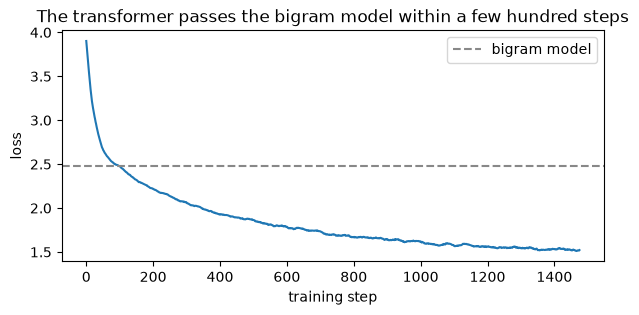



CORIOLANUS:
The cannot that every hate house true virtues and her
To rail. O, and whican ever
Which grades put of But hithers bears:
Whose there fest, as are the man, my be is the earth.

FLORIZEL:
We'ce not the denial to atter
Word that put Warwick in a the Hangless, hearting he tend
With them the bid forth my lord pasina fait
That shall grave sweet have lip news, thou haps
Have think less and guves thee offench'd fight
OF Menger:
He the that hand interproase to make us brother.

COMINIUS:
Tha


In [10]:
plt.figure(figsize=(7, 3))
plt.plot(np.convolve(losses, np.ones(25) / 25, mode="valid"))
plt.axhline(nll, color="#888", ls="--", label="bigram model")
plt.xlabel("training step"); plt.ylabel("loss"); plt.legend(); plt.title("The transformer passes the bigram model within a few hundred steps")
plt.show()

torch.manual_seed(1)
print(write(model, "\n", length=500))

## 6. Bold or safe? Temperature

To write, the model picks the next character at random, in proportion to its probabilities.
Dividing the scores by a **temperature** before softmax changes how bold the picks are.

### 🤔 Predict first

**What happens at temperature 0.2? At 2.0?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

At **0.2**, the top choice nearly always wins: safe, repetitive text that loops on common words. At **2.0**, unlikely characters get picked often: rambling, misspelled text.

</details>

In [11]:
for t in (0.2, 0.8, 2.0):
    torch.manual_seed(2)
    print(f"--- temperature {t} ---")
    print(write(model, "The ", length=200, temperature=t), "\n")

--- temperature 0.2 ---


The can the sent the seat to the comes of the words
Than a the the seems of the banish of the words
That should be so the seems of the death.

POMPEY:
What shall be the with the words to my lord,
What tho 

--- temperature 0.8 ---


The came, lord;
We so you to say my sons, the write ween my us,
Whered meet the batts word, marrel no ance.

PRINCE EDWARD:

HENRY S:
We sures, sir, for that that my care cliff Clarence,
And plood my char 

--- temperature 2.0 ---


The cdil, lone;y,e's roth'to!Y UnviogNXHN:
Isanry'. Sten mCtuget, hisdree,
Onle'bREFs Roboy!m:
Goler? ancoc, leniva,'
--ten;
He falk zedys,
Ufelsie& f; cadly. say!
I chaugcligO lifets: JulipG; got?F
Gendo 



### What does each head look at?

Each row of a heatmap is one character in the phrase; bright squares are the earlier characters it gives most weight to.

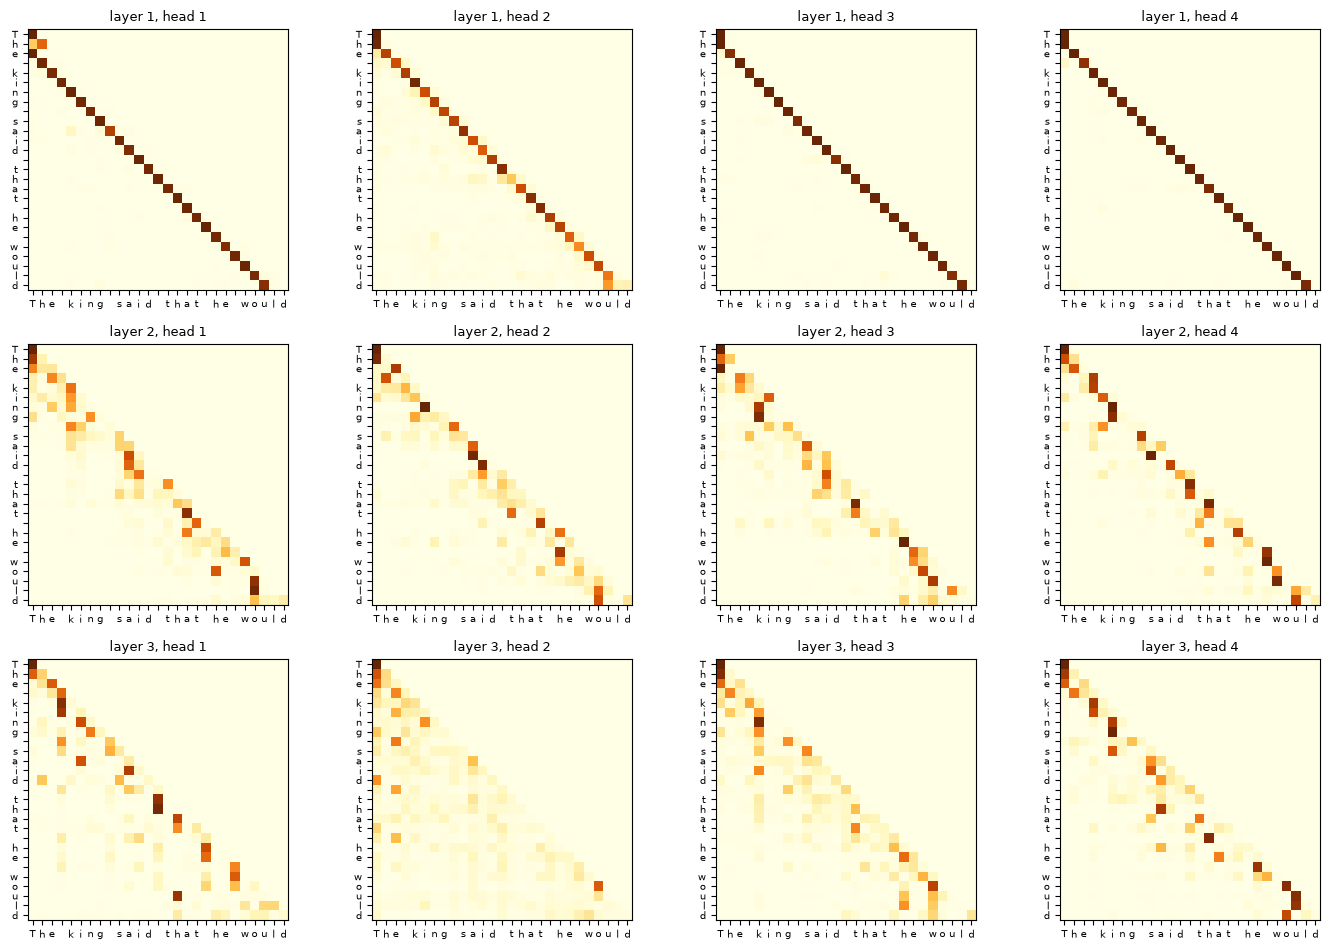

In [12]:
phrase = "The king said that he would"
idx = torch.tensor([[stoi.get(c, 0) for c in phrase]])
model.eval()
with torch.no_grad():
    model(idx)
model.train()

fig, axes = plt.subplots(LAYERS, HEADS, figsize=(14, 3.2 * LAYERS))
for L in range(LAYERS):
    for H in range(HEADS):
        ax = axes[L][H]
        ax.imshow(model.blocks[L].heads[H].last_weights[0].numpy(), cmap="YlOrBr")
        ax.set_xticks(range(len(phrase))); ax.set_xticklabels(list(phrase), fontsize=7)
        ax.set_yticks(range(len(phrase))); ax.set_yticklabels(list(phrase), fontsize=7)
        ax.set_title(f"layer {L + 1}, head {H + 1}", fontsize=9)
plt.tight_layout(); plt.show()

**What you see:** heads differ. Some look mostly at the character directly before (a bright stripe just left of the diagonal). Some look back to the last space or the start of the word.
Nobody programmed these patterns; they came from training. Working out what heads like these do is the job of [interpretability](https://transformer-circuits.pub/), Field 4.

## 7. Bigger tokens: byte-pair encoding

Real models don't use single characters: sequences would be long and each step would carry little meaning.
They use pieces of words, found by a **greedy** rule:

1. Start with single characters.
2. Find the most common **pair** of neighbouring tokens. Merge it into one new token.
3. Repeat.

In [13]:
from collections import Counter

def bpe(words, merges=20):
    seqs = [list(w) for w in words]
    learned = []
    for _ in range(merges):
        pairs = Counter()
        for s in seqs:
            for a, b in zip(s, s[1:]):
                pairs[(a, b)] += 1
        if not pairs:
            break
        (a, b), count = pairs.most_common(1)[0]
        learned.append((a + b, count))
        for s in seqs:                                  # replace the pair everywhere
            i = 0
            while i < len(s) - 1:
                if s[i] == a and s[i + 1] == b:
                    s[i:i + 2] = [a + b]
                else:
                    i += 1
    return learned, seqs

sample_words = text[:60_000].lower().split()
learned, seqs = bpe(sample_words, merges=25)
print("merges, in order:", [m for m, _ in learned])
long_words = [w for w in dict.fromkeys(sample_words) if len(w) >= 8 and w.isalpha()][:5]
for w in long_words:
    print(f"{w!r} becomes:", seqs[sample_words.index(w)])

merges, in order: ['th', 'ou', 'the', 'an', 'in', 're', 'en', 'us', 'er', 'at', 'or', 'on', 'ar', 'you', 'es', 'll', 'to', 'is', 'he', 'and', 'it', 'ius', 'no', 'st', 'om']
'resolved' becomes: ['re', 's', 'o', 'l', 'v', 'e', 'd']
'accounted' becomes: ['a', 'c', 'c', 'ou', 'n', 't', 'e', 'd']
'patricians' becomes: ['p', 'at', 'r', 'i', 'c', 'i', 'an', 's']
'authority' becomes: ['a', 'u', 'th', 'or', 'it', 'y']
'surfeits' becomes: ['s', 'u', 'r', 'f', 'e', 'it', 's']


🐍 `Counter` (from `collections`) is a dict that counts: `pairs[(a, b)] += 1` works without setting a starting value, and `most_common(1)` returns the top entry.

**What you see:** early merges are common pairs like "th", "he", "in"; later ones become whole short words. Each step takes the best-looking merge right now without planning ahead: a **greedy algorithm**. Counting pairs uses a **hash map** (the `Counter`).

## Practice

Try each one before opening its solution.

### Exercise 1

By hand: scores for three characters are 2, 1 and 0. **What are the probabilities at temperature 1? At temperature 0.5?**

<details><summary><b>Show the answer to exercise 1</b></summary>

Temperature 1: $e^2, e^1, e^0 = 7.39, 2.72, 1$; total 11.11 → **67%, 24%, 9%**. Temperature 0.5 doubles the scores to 4, 2, 0: $54.6, 7.39, 1$; total 63.0 → **87%, 12%, 2%**. Lower temperature sharpens the choice.

</details>

### Exercise 2

Write a function `most_likely_after(context)` that returns the transformer's 5 most likely next characters (with probabilities) after any string. Try the start of a word that is common in your book, like `"The ki"` or `"my lo"`.

In [14]:
def most_likely_after(context):
    ...

In [15]:
#@title Solution to exercise 2 (double-click to show)
@torch.no_grad()
def most_likely_after(context, k=5):
    model.eval()
    idx = torch.tensor([[stoi.get(c, 0) for c in context[-BLOCK:]]])
    p = F.softmax(model(idx)[0, -1], dim=-1)
    top = torch.topk(p, k)
    model.train()
    return [(itos[int(i)], round(float(v), 3)) for v, i in zip(top.values, top.indices)]

for ctx in ["The ki", "my lo", "What "]:
    print(repr(ctx), most_likely_after(ctx))

'The ki' [('n', 0.845), ('l', 0.075), ('s', 0.04), ('g', 0.007), ('t', 0.007)]
'my lo' [('r', 0.701), ('s', 0.097), ('v', 0.088), ('n', 0.047), ('o', 0.02)]
'What ' [('t', 0.121), ('s', 0.099), ('i', 0.087), ('w', 0.078), ('I', 0.064)]


### Exercise 3

The model can only look back 64 characters. **Find a way to show that limit in its writing**, for example a name that is introduced and then forgotten.

In [16]:
# your experiment here

<details><summary><b>Show the answer to exercise 3</b></summary>

One way: start writing from a prompt that names someone, generate 400 characters, and check whether the name comes back after more than 64 characters. Then set `BLOCK = 16`, retrain, and compare. A shorter window makes the text lose track of who and what it is about sooner.

</details>

## Recognition cues

- When you see **"predict what comes next in a sequence"** in a problem, think **next-token prediction, trained with cross-entropy**.
- When you see **"each item should use information from the relevant earlier items"** in a problem, think **attention: queries, keys, values**.
- When you see **"output too repetitive, or too random"** in a problem, think **change the sampling temperature**.
- When you see **"merge the most frequent pair, repeat"** in a problem, think **a greedy algorithm (byte-pair encoding) with a hash map of counts**.

## Try changing this

1. **One layer, one head.** Set `LAYERS = 1` and `HEADS = 1`, retrain, and compare the loss and the writing.
2. **A different book.** Swap the first URL in `SOURCES` for another public-domain text on Project Gutenberg. Does the style follow?
3. **Shorter memory.** Set `BLOCK = 8`. How much worse is the loss? What does the text lose?

## Open research questions

People are working on these right now:

- How do models reason over many steps?
- Why do they sometimes make things up? (Your model invents words and names that look right: the same effect, small.)

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **Language models** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- Andrej Karpathy, *Let's build GPT: from scratch, in code* (about 2 hours; builds a model like this one, step by step): https://www.youtube.com/watch?v=kCc8FmEb1nY
- The site's showpiece *A tiny language model you can see inside* runs a bigger version of this model in your browser.
- At Monash: FIT5217 Natural language processing.